In [1]:
from pathlib import Path

def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise SystemExit("ไม่พบโฟลเดอร์ datasets/ — เปิด JupyterLab จาก repo root (uv run jupyter lab)")

DATA = data_dir()

**Dataset ที่ใช้ในโมดูลนี้ (โปรดอ่านก่อนใช้งาน):**

- *SECOM* — McCann, M. & Johnston, A. (2008). *SECOM* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C54305 (CC BY 4.0)
- *Combined Cycle Power Plant* — Tüfekci, P. & Kaya, H. (2014). *Combined Cycle Power Plant* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5002N (CC BY 4.0)

ไฟล์: `datasets/secom.zip`, `datasets/ccpp_power_plant.csv`

# Module 5 — Model Evaluation: Judging Models the Metrology Way

ในโมดูลนี้เราไม่ได้สร้างโมเดลใหม่ที่ฉลาดขึ้น — เราสร้าง **ไม้บรรทัดสำหรับวัดโมเดล** แทน

**สิ่งที่ผู้เรียนต้องมีติดตัวมาก่อน (prerequisites):**

- จาก **Module 4** (classification): การสร้าง scikit-learn `Pipeline`, การแบ่ง train/test ด้วย `train_test_split`, และการ fit/predict โมเดลคลาสิฟิเคชันพื้นฐาน
- จาก **Day 1 Module 3** (regression): การอ่าน R², residual plot, และโมเดล Ridge บน CCPP
- ไม่ต้องมีความรู้เรื่อง evaluation มาก่อน — นั่นคือหน้าที่ของโมดูลนี้

**ประเด็นหลักของโมดูล:** ในงานเมโทรโลยี เราไม่ยอมรับเครื่องมือวัดที่ไม่มีใบสอบเทียบ แล้วทำไมเราถึงยอมรับโมเดล ML ที่รายงานแค่ "accuracy 93%"? โมดูลนี้จะสอนการประเมินโมเดลอย่างตรงไปตรงมา (honest evaluation) ทั้งงานคลาสิฟิเคชัน (SECOM — ตรวจสอบผลิตภัณฑ์ผ่าน/ตก) และงานรีเกรสชัน (CCPP — ทำนายค่ากำลังไฟฟ้า)

## 1. โหลด SECOM และเทรนโมเดล "ผู้ถูกพิจารณา"

SECOM คือข้อมูลจริงจากสายผลิตภัณฑ์เซมิคอนดักเตอร์: แต่ละแถวคือผลิตภัณฑ์หนึ่งชิ้น วัดด้วยเซนเซอร์กระบวนการผลิต **590 ตัวแปร** และ label บอกว่าชิ้นงานนั้น **PASS (-1)** หรือ **FAIL (1)** ข้อมูลมี missing values เยอะ (~4.5% ของเซลล์ทั้งหมด) — เราจัดการด้วย `SimpleImputer` ใน pipeline (เราเคยเรียนใน Module 4)

เราใช้ **time-based split**: ข้อมูลเรียงตามเวลาผลิตอยู่แล้ว เราจึงเทรนด้วย 80% แรกและทดสอบด้วย 20% ท้าย — เหมือนส่งเครื่องมือไปใช้กับล็อตผลิตภัณฑ์**อนาคต** ที่ยังไม่เคยเห็น

In [2]:
import io
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# SECOM ships as an official UCI zip: secom.data (features) + secom_labels.data (label + timestamp)
with zipfile.ZipFile(DATA / "secom.zip") as z:
    feats = pl.read_csv(
        io.BytesIO(z.read("secom.data")),
        separator=" ", has_header=False,
        new_columns=[f"feature_{i}" for i in range(1, 591)],
        schema_overrides={f"feature_{i}": pl.Float64 for i in range(1, 591)},
    )
    lab = pl.read_csv(
        io.BytesIO(z.read("secom_labels.data")),
        separator=" ", quote_char='"', has_header=False,
        new_columns=["label", "timestamp"],
        schema_overrides={"label": pl.Int64, "timestamp": pl.Utf8},
    )

y = (lab["label"] == 1).to_numpy().astype(int)  # 1 = FAIL (positive class), 0 = PASS
X = feats.to_numpy()
print(f"SECOM: {X.shape[0]} rows x {X.shape[1]} features, fails = {y.sum()} ({y.mean():.1%})")

# time-based split: rows are already in production order
cut = int(len(y) * 0.8)
X_train, X_test, y_train, y_test = X[:cut], X[cut:], y[:cut], y[cut:]
print(f"train: {len(y_train)} rows ({y_train.sum()} fails) | test: {len(y_test)} rows ({y_test.sum()} fails)")

clf = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=42),
)
clf.fit(X_train, y_train)
y_proba = clf.predict_proba(X_test)[:, 1]   # P(FAIL) ต่อชิ้นงาน
y_pred = (y_proba >= 0.5).astype(int)       # ตัดสินใจที่ threshold 0.5 ก่อน (จะปรับทีหลัง)
print("done — model fitted, test predictions ready")

SECOM: 1567 rows x 590 features, fails = 104 (6.6%)
train: 1253 rows (87 fails) | test: 314 rows (17 fails)
done — model fitted, test predictions ready


โมเดลของเราคือ logistic regression ธรรมดา (เทรนเสร็จในไม่กี่วินาที) — เป้าหมายของโมดูลนี้ไม่ใช่ทำให้โมเดลเก่ง แต่ทำให้ **การตัดสินว่าโมเดลเก่งแค่ไหน** ถูกต้องและซื่อสัตย์

## 2. Confusion matrix — ตารางตัดสินใจของ QC lab

ก่อนดู metric ใด ๆ ให้ดู **confusion matrix** ก่อนเสมอ: ตาราง 2×2 ที่เทียบ "ความจริง" กับ "คำตัดสินของโมเดล" ในภาษาของงานตรวจสอบคุณภาพ (QC):

- **TP** (true positive) — โมเดลตัด FAIL ออกถูกต้อง → กันของเสียออกจากสายได้
- **TN** (true negative) — โมเดลปล่อย PASS ผ่านถูกต้อง → สายผลิตไหลลื่น
- **FN** (false negative) = **false accept** — **ปล่อยของเสียผ่าน** ไปถึงลูกค้า ← *ความเสียหายร้ายแรงที่สุดของการตัดสิน gauge: สูญเสียความน่าเชื่อถือ ทำให้เกิด recall/field failure*
- **FP** (false positive) = **false reject** — **ตัดของดีทิ้ง** (หรือส่งกลับมา re-inspect) ← เสียต้นทุน แต่ตรวจพบได้ในบ้านของเราเอง

TN (pass, จับถูกปล่อยผ่าน) = 290
FP (false reject — ตัดของดีทิ้ง) = 7
FN (false accept — ปล่อยของเสียผ่าน) = 15
TP (fail, จับได้) = 2


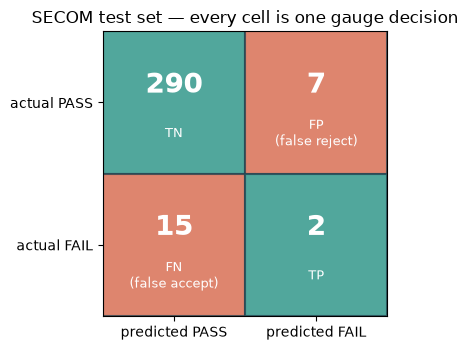

In [3]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"TN (pass, จับถูกปล่อยผ่าน) = {tn}")
print(f"FP (false reject — ตัดของดีทิ้ง) = {fp}")
print(f"FN (false accept — ปล่อยของเสียผ่าน) = {fn}")
print(f"TP (fail, จับได้) = {tp}")

# annotated confusion matrix, metrology reading
labels = [["TN", "FP\n(false reject)"], ["FN\n(false accept)", "TP"]]
colors = [["#2a9d8f", "#e76f51"], ["#e76f51", "#2a9d8f"]]  # teal = correct, orange-red = error

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.imshow(np.ones_like(cm), cmap="Greys", vmin=0, vmax=3)
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=colors[i][j], alpha=0.75, edgecolor="#264653", linewidth=1.5))
        ax.text(j, i - 0.12, str(cm[i, j]), ha="center", va="center", fontsize=20, fontweight="bold", color="white")
        ax.text(j, i + 0.22, labels[i][j], ha="center", va="center", fontsize=9, color="white")
ax.set_xticks([0, 1], ["predicted PASS", "predicted FAIL"])
ax.set_yticks([0, 1], ["actual PASS", "actual FAIL"])
ax.set_title("SECOM test set — every cell is one gauge decision")
plt.tight_layout()
plt.show()

**อ่านตัวเลขแบบนักเมโทรโลยี:** จาก 314 ชิ้นงานทดสอบ โมเดลตัดสินผิด 22 ครั้ง แต่ **ผิดไม่เท่ากัน**: ตัดของดีทิ้ง 7 ชิ้น (FP — เสียแค่เวลา re-inspect) แต่ **ปล่อยของเสียผ่านไป 15 ชิ้น** (FN — ของเสียหลุดออกไปหาลูกค้า) สองตัวเลขนี้คือหัวใจ — accuracy ตัวเดียวกลืนมันหายไปหมด

## 3. Precision, recall, F1 — และเหตุผลที่ accuracy โกหก

นิยาม (ใช้ FAIL = positive class):

- **Accuracy** = ตัดสินถูกทั้งหมด / ทั้งหมด — ดูสมมารถ แต่ถูกข้อมูลไม่สมดุลหลอกง่าย
- **Precision** = TP / (TP + FP) — "พอโมเดลสั่งหยุด/ตัดชิ้นงาน กี่เปอร์เซ็นต์ที่เป็นของเสียจริง" (ความน่าเชื่อถือของการตัดสินตัดออก)
- **Recall** (sensitivity) = TP / (TP + FN) — "ของเสียทั้งหมด จับได้กี่เปอร์เซ็นต์" = **1 − false accept rate** ในแง่ที่ QC สนใจ
- **F1** = harmonic mean ของ precision และ recall — ต่ำฝั่งใดฝั่งหนึ่งก็โดนลง (จับความไม่สมดุลของสองค่าได้ดีกว่า arithmetic mean)

ทำไม accuracy โกหก: ใน SECOM ของเสียมีแค่ **6.6%** โมเดลที่ **เดา "PASS" ทุกชิ้นโดยไม่คิดเลย** ก็ได้ accuracy ≈ 93.4% ทันที แต่จับของเสียได้ 0% — ในงาน QC นี่คือ gauge ที่ใช้ไม่ได้เลย

In [4]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"accuracy  = {acc:.3f}   <- ดูดี แต่...")
print(f"precision = {prec:.3f}   (ตอบ: ตัดออกแล้วเป็นของเสียจริงแค่ไหน)")
print(f"recall    = {rec:.3f}   (ตอบ: ของเสียทั้งหมดจับได้แค่ไหน)")
print(f"F1        = {f1:.3f}")

lazy = np.zeros_like(y_test)  # โมเดลเกเร: เดา PASS ทุกชิ้น
print(f"\nโมเดลเกเรที่เดา PASS ทุกชิ้น: accuracy = {accuracy_score(y_test, lazy):.3f} แต่ recall = {recall_score(y_test, lazy, zero_division=0):.3f}")

accuracy  = 0.930   <- ดูดี แต่...
precision = 0.222   (ตอบ: ตัดออกแล้วเป็นของเสียจริงแค่ไหน)
recall    = 0.118   (ตอบ: ของเสียทั้งหมดจับได้แค่ไหน)
F1        = 0.154

โมเดลเกเรที่เดา PASS ทุกชิ้น: accuracy = 0.946 แต่ recall = 0.000


**ทางออกของความล้มเหลว 93% แบบโมเดลเกเร:** ค่า accuracy ของเรา (0.930) กับของโมเดลเกเร (0.946) ต่างกันนิดเดียว แต่ **recall** บอกความต่างที่แท้จริง — เมื่อ positive class จิ๋ว ให้รายงาน precision/recall/F1 และ AUC (หัวข้อ 5) เสมอ **ไม่ใช่ accuracy เดี่ยว ๆ**

## 4. Threshold sweep — เกจดิจิทัลต้องเลือกจุดตัดสิน

`predict` ใช้ threshold 0.5 โดยดุลยภาพ แต่ใน QC เราเลือก threshold จาก **ต้นทุนของความผิดพลาดสองฝั่ง**:

- **threshold ต่ำ** → ตัดสิน FAIL ง่ายขึ้น → recall สูง (จับของเสียได้มาก) แต่ false reject เยอะ (ตัดของดีทิ้ง, เสีย re-inspection)
- **threshold สูง** → ปล่อยผ่านง่ายขึ้น → precision สูงแต่ **false accept** เพิ่ม (ของเสียหลุดไปลูกค้า — แพงกว่ามาก)

ลองกวาด threshold จาก 0.05 ถึง 0.9 แล้วดู precision/recall/F1 ที่แต่ละจุด

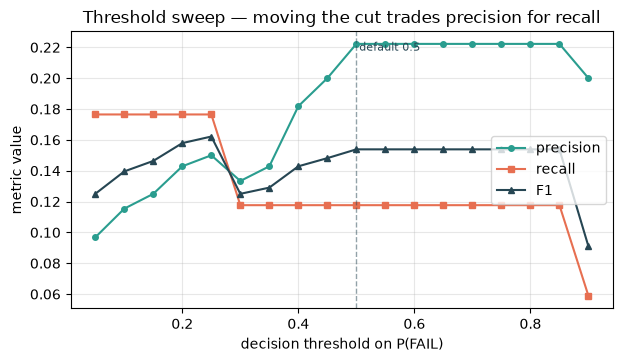

In [5]:
thresholds = np.round(np.arange(0.05, 0.91, 0.05), 2)
sweep = {"threshold": [], "precision": [], "recall": [], "f1": []}
for t in thresholds:
    pred_t = (y_proba >= t).astype(int)
    sweep["threshold"].append(t)
    sweep["precision"].append(precision_score(y_test, pred_t, zero_division=0))
    sweep["recall"].append(recall_score(y_test, pred_t, zero_division=0))
    sweep["f1"].append(f1_score(y_test, pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(sweep["threshold"], sweep["precision"], color="#2a9d8f", marker="o", ms=4, label="precision")
ax.plot(sweep["threshold"], sweep["recall"], color="#e76f51", marker="s", ms=4, label="recall")
ax.plot(sweep["threshold"], sweep["f1"], color="#264653", marker="^", ms=4, label="F1")
ax.axvline(0.5, color="#264653", linestyle="--", linewidth=1, alpha=0.5)
ax.text(0.505, 0.93, "default 0.5", transform=ax.get_xaxis_transform(), fontsize=8, color="#264653")
ax.set_xlabel("decision threshold on P(FAIL)")
ax.set_ylabel("metric value")
ax.set_title("Threshold sweep — moving the cut trades precision for recall")
ax.legend(loc="center right")
ax.grid(alpha=0.3)
plt.show()

**สังเกต:** เส้น precision/recall ไม่ได้ไหลเนียนเป็นคลื่น — มัน **เป็นขั้นบันได** เพราะชุดทดสอบมีของเสียแค่ 17 ชิ้น (ย้าย threshold เล็กน้อยไม่เปลี่ยนการตัดสินเลยจนถึงชิ้นถัดไป) นี่คืออีกเหตุผลที่ตัวเลขจาก test set เล็ก ๆ ต้องอ่านอย่างระวัง — เหมือนความละเอียดของไม้บรรทัดที่มีขีดห่างกัน

**QC lab จะตั้งตรงไหน?** ไม่มีคำตอบสากล — ขึ้นกับต้นทุน: false accept (ปล่อยของเสียผ่าน) ทำให้เกิด **recall/field failure** ที่แพงมหาศาล ส่วน false reject (ตัดของดีทิ้ง) เสียแค่ค่า re-inspection ถ้า false accept แพงกว่า เราจะเลื่อน threshold **ลง** เพื่อซื้อ recall ด้วย precision (exercise ข้อ A3 จะให้คิดตัวเลขจริง)

## 5. ROC curve และ PR curve — คะแนนที่ไม่ขึ้นกับจุดตัดสิน

Threshold sweep ต้องเลือกจุดเดียว แต่เราอยากได้ **คะแนนรวมของโมเดลทุกจุดตัดสินพร้อมกัน**:

- **ROC curve** — plot TPR (recall) กับ FPR (false reject rate บนของดี) ขณะกวาด threshold **AUC = 1.0** คือจัดเรียงชิ้นงานถูกต้องทุกคู่ **0.5** คือเดาสุ่ม (เส้นทแยง)
- **PR curve** — plot precision กับ recall เส้นฐาน (baseline) คือ **อัตราของเสีย (5.4% ใน test set)** ไม่ใช่ 0.5

**ทำไม PR-AUC ซื่อสัตย์กว่าเมื่อข้อมูลไม่สมดุล:** ROC ใช้ FPR = FP/TN และ TN ของเรามี **290 ตัว** — ตัวเลข FP ที่ดูน่ากลัวถูกเจือจางด้วย TN มหาศาล ทำให้ ROC-AUC สู้ได้ง่ายแม้ precision แย่ ส่วน PR curve ใช้ precision ที่คำนวณจาก **FP ต่อจำนวนที่ตัดออกจริง** — ตัวเลขที่ QC manager อ่านตรง ๆ ว่า "ตัดออกแล้วขยะกี่เปอร์เซ็นต์" เมื่อของเสีย 6.6% PR-AUC จึงเป็นไม้บรรทัดที่เข้มงวดกว่า

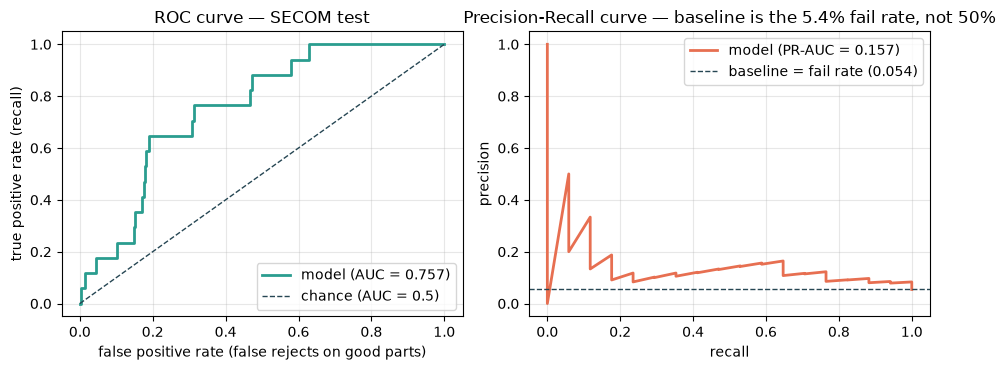

ROC-AUC = 0.757 | PR-AUC = 0.157 | baseline PR-AUC (เดาสุ่ม) ≈ 0.054
ตีความ: จัดเรียงคู่ (fail, pass) ถูก 76% | precision เฉลี่ยบนของเสียสูงกว่าเดาสุ่ม ~2.9 เท่า


In [6]:
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba)
prec_c, rec_c, _ = precision_recall_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
axes[0].plot(fpr, tpr, color="#2a9d8f", linewidth=2, label=f"model (AUC = {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], color="#264653", linestyle="--", linewidth=1, label="chance (AUC = 0.5)")
axes[0].set_xlabel("false positive rate (false rejects on good parts)")
axes[0].set_ylabel("true positive rate (recall)")
axes[0].set_title("ROC curve — SECOM test")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

axes[1].plot(rec_c, prec_c, color="#e76f51", linewidth=2, label=f"model (PR-AUC = {pr_auc:.3f})")
axes[1].axhline(y_test.mean(), color="#264653", linestyle="--", linewidth=1, label=f"baseline = fail rate ({y_test.mean():.3f})")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].set_title("Precision-Recall curve — baseline is the 5.4% fail rate, not 50%")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC = {roc_auc:.3f} | PR-AUC = {pr_auc:.3f} | baseline PR-AUC (เดาสุ่ม) ≈ {y_test.mean():.3f}")
print(f"ตีความ: จัดเรียงคู่ (fail, pass) ถูก {roc_auc:.0%} | precision เฉลี่ยบนของเสียสูงกว่าเดาสุ่ม ~{pr_auc / y_test.mean():.1f} เท่า")

**อ่านค่า:** ROC-AUC 0.757 ฟังดู "โอเค" แต่ PR-AUC 0.157 บอกความจริงที่เจ็บปวดกว่า — precision เฉลี่ยเมื่อโฟกัสของเสียอยู่ราว 3 เท่าของการเดาสุ่ม เท่านั้น ถ้าเราตัดสินจาก ROC-AUC อย่างเดียว เราจะมั่นใจเกินจริง — เส้น ROC ที่โค้งสวยถูก "เสริมฟอร์ม" ด้วย TN เพียบในข้อมูลไม่สมดุล

## 6. Cross-validation ที่ถูกต้อง — อ่าน spread ของ metric แบบอ่าน repeatability

ค่า metric จาก **test set เดียว** คือการวัด **ครั้งเดียว** — นักเมโทรโลยีไม่เชื่อการวัดครั้งเดียว `StratifiedKFold` แบ่งข้อมูลเป็น 5 folds โดยรักษาอัตราของเสีย 6.6% ให้เท่ากันทุก fold แล้วเวียนฝึก/ทดสอบ

**ทำไมต้อง `shuffle=True, random_state=42` (stratification):** ถ้า `shuffle=False` fold แต่ละอันจะก้อนติดกันตามเวลาผลิต แล้ว fold ที่ตรงช่วงกระบวนการผันผวนจะยากผิดปกติ (เราลองแล้ว: ROC-AUC แกว่งจาก 0.53 ถึง 0.72 — งานวัดแบบนั้นไม่ repeatable พอจะอ่านได้) เราจึงสุ่ม+stratify เพื่อให้ทุก fold มีอัตราของเสียเท่ากัน แล้วรักษาเรื่อง "เวลา" ไว้ให้หัวข้อ 7 ซึ่งเทียบแบบเปิดเผย — และกำหนด `random_state=42` เพื่อให้ทุกคนได้ folds ชุดเดียวกัน

In [7]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]
cv_res = cross_validate(clf, X, y, cv=cv, scoring=scoring)

print(f"{'metric':<20s}{'mean':>8s}{'±std':>8s}   folds")
for s in scoring:
    v = cv_res[f"test_{s}"]
    print(f"{s:<20s}{v.mean():>8.3f}{v.std():>8.3f}   {np.round(v, 3)}")

metric                  mean    ±std   folds
accuracy               0.886   0.010   [0.876 0.889 0.901 0.891 0.875]
precision              0.150   0.019   [0.154 0.15  0.176 0.118 0.154]
recall                 0.154   0.035   [0.19  0.143 0.15  0.095 0.19 ]
f1                     0.151   0.024   [0.17  0.146 0.162 0.105 0.17 ]
roc_auc                0.660   0.023   [0.676 0.653 0.64  0.635 0.696]
average_precision      0.148   0.028   [0.137 0.117 0.125 0.182 0.181]


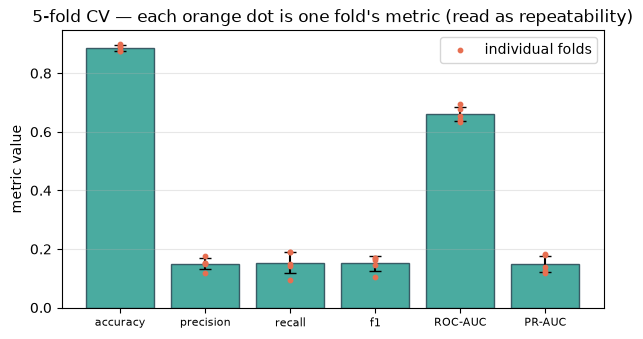

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.6))
names = ["accuracy", "precision", "recall", "f1", "ROC-AUC", "PR-AUC"]
vals = [cv_res["test_accuracy"], cv_res["test_precision"], cv_res["test_recall"],
        cv_res["test_f1"], cv_res["test_roc_auc"], cv_res["test_average_precision"]]
means = [v.mean() for v in vals]
stds = [v.std() for v in vals]
xpos = np.arange(len(names))
ax.bar(xpos, means, yerr=stds, capsize=4, color="#2a9d8f", edgecolor="#264653", alpha=0.85)
ax.scatter(np.repeat(xpos, 5), np.concatenate(vals), s=10, color="#e76f51", zorder=3, label="individual folds")
ax.set_xticks(xpos, names, fontsize=8)
ax.set_ylabel("metric value")
ax.set_title("5-fold CV — each orange dot is one fold's metric (read as repeatability)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.show()

**อ่านแบบนักเมโทรโลยี:** std ของแต่ละ metric คือ **repeatability ของการประเมิน** — recall ±0.035 กับ PR-AUC ±0.028 คือขนาดความไม่แน่นอนของไม้บรรทัดตัวนี้เอง ถ้าเราเทียบโมเดลสองตัวแล้วต่างกันน้อยกว่า spread นี้ **อย่ารีบสรุปว่าตัวใดดีกว่า** ทำนองเดียวกับที่เราไม่สรุปความต่างของเครื่องมือสองชิ้นที่เล็กกว่า uncertainty ของการวัด

## 7. Random split vs time split — การสุ่มอาจทำให้คะแนนสวยเกินจริง

ตอนนี้มาถึงคำถามที่สำคัญที่สุดของการประเมินโมเดลบนข้อมูลผลิตภัณฑ์: **เราแบ่ง train/test อย่างไร?**

- **Random split** — สลับการ์ดก่อนแบ่ง ชิ้นงานที่ผลิตใกล้กัน (สภาวะกระบวนการใกล้กัน) กระจายอยู่ทั้งฝั่ง train และ test
- **Time split** — เทรนด้วยอดีต ทดสอบด้วยอนาคต ตรงกับการใช้งานจริง: โมเดลถูก deploy ไปตัดสินใจกับ **ล็อตใหม่** ที่โมเดลไม่เคยเห็น

เราเทียบสองวิธีกับโมเดลสองตัว: logistic regression (เส้นตรง) และ RandomForest (ยืดหยุ่นกว่ามาก — จำ local pattern ได้)

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

def time_split_metrics(model, X, y, frac=0.8):
    """Fit on the first frac, test on the tail — mirrors deployment."""
    c = int(len(y) * frac)
    m = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), model).fit(X[:c], y[:c])
    p = m.predict_proba(X[c:])[:, 1]
    return roc_auc_score(y[c:], p), average_precision_score(y[c:], p)

def random_split_metrics(model, X, y, seed=42):
    """Stratified random split — convenient but leaks process context."""
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    m = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), model).fit(Xtr, ytr)
    return roc_auc_score(yte, m.predict_proba(Xte)[:, 1]), average_precision_score(yte, m.predict_proba(Xte)[:, 1])

models = {
    "Logistic": LogisticRegression(max_iter=2000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
}
rows = []
for name, mdl in models.items():
    roc_t, pr_t = time_split_metrics(mdl, X, y)
    roc_r, pr_r = random_split_metrics(mdl, X, y)
    rows.append((name, roc_r, roc_t, pr_r, pr_t))
    print(f"{name:12s}  ROC-AUC: random={roc_r:.3f}  time={roc_t:.3f} (Δ={roc_r-roc_t:+.3f})   PR-AUC: random={pr_r:.3f}  time={pr_t:.3f} (Δ={pr_r-pr_t:+.3f})")

Logistic      ROC-AUC: random=0.641  time=0.757 (Δ=-0.117)   PR-AUC: random=0.121  time=0.157 (Δ=-0.037)


RandomForest  ROC-AUC: random=0.763  time=0.515 (Δ=+0.249)   PR-AUC: random=0.220  time=0.063 (Δ=+0.157)


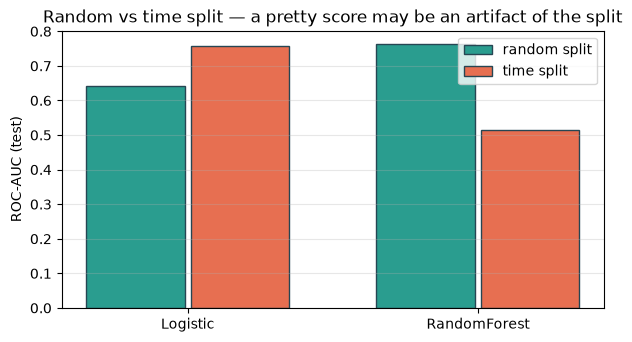

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.6))
labels_r = [r[0] for r in rows]
xpos = np.arange(len(rows))
ax.bar(xpos - 0.18, [r[1] for r in rows], width=0.34, color="#2a9d8f", label="random split", edgecolor="#264653")
ax.bar(xpos + 0.18, [r[2] for r in rows], width=0.34, color="#e76f51", label="time split", edgecolor="#264653")
ax.set_xticks(xpos, labels_r)
ax.set_ylabel("ROC-AUC (test)")
ax.set_title("Random vs time split — a pretty score may be an artifact of the split")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.show()

**บทเรียนที่ซื่อสัตย์:** ตัวเลขจาก SECOM ไม่ได้เรียงสวยทางเดียว — RF โดน random split **ทำให้ฟู** อย่างชัดเจน (ROC-AUC ~0.76 ร่วงเหลือ ~0.52 เมื่อทดสอบกับอนาคต เพราะ RF จำสภาวะกระบวนการเฉพาะช่วงเวลาได้) ส่วน logistic กลับได้คะแนน time split สูงกว่า random ใน seed นี้ — ประเด็นจึงไม่ใช่ "random สูงเสมอ" แต่คือ **ผลประเมินแกว่งตามวิธีแบ่งข้อมูลอย่างมาก** และมีวิธีเดียวที่เลียนแบบการใช้งานจริง: **time split** เมื่อข้อมูลผลิตมี drift การรายงานคะแนนจาก random split จึงเสี่ยงที่สุดกับโมเดลที่ยืดหยุ่นสูง และแนวปฏิบัติที่ปลอดภัยคือรายงาน **ทั้งสองแบบ** พร้อมเขียนกำกับว่าใช้ split แบบใด — เหมือนบันทึก "ช่วงการสอบเทียบ" บนใบ certificate

## 8. Regression metrics — R², RMSE, MAE, และ residual บน CCPP

จาก Day 1 เรา fit Ridge บน CCPP (ทำนาย `PE` กำลังไฟฟ้าจากตัวแปรสภาพแวดล้อม 4 ตัว) ตอนนี้เรามา **ตัดสิน** มันด้วย metric ที่เหมาะกับงานวัด:

- **R²** — สัดส่วนความแปรปรวนที่โมเดลอธิบายได้ (dimensionless, ใช้เทียบโมเดลได้ แต่ไม่บอกหน่วยความคลาดเคลื่อน)
- **RMSE** = √mean(e²) — คลาดเคลื่อนเฉลี่ยใน **หน่วยของ y เอง (MW)** — โดน error ใหญ่ (outlier) หนักกว่า
- **MAE** = mean|e| — คลาดเคลื่อนเฉลี่ยแบบเส้นตรง ทน outlier กว่า
- **MAPE-style relative error** = mean|e/y| — คิดเป็น % ของค่าจริง อ่านสื่อสารง่าย (แต่ระวัง y ใกล้ศูนย์)

และที่ขาดไม่ได้สำหรับนักเมโทรโลยี: **residual plot** — แยกความคลาดเคลื่อนออกเป็น **bias** (เอียงเป็นระบบ ตัดสินใจแก้ได้) กับ **spread** (scatter รอบศูนย์ — ความละเอียดของโมเดล)

In [11]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ccpp = pl.read_csv(DATA / "ccpp_power_plant.csv")
print(f"CCPP: {ccpp.shape[0]} rows x {ccpp.shape[1]} cols")
Xc = ccpp.select("AT", "V", "AP", "RH").to_numpy()
yc = ccpp["PE"].to_numpy()
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2, random_state=42)

ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xc_tr, yc_tr)
pred_pe = ridge.predict(Xc_te)
resid = yc_te - pred_pe

r2 = r2_score(yc_te, pred_pe)
rmse = float(np.sqrt(mean_squared_error(yc_te, pred_pe)))
mae = mean_absolute_error(yc_te, pred_pe)
mape = float(np.mean(np.abs(resid / yc_te)) * 100)
print(f"R²   = {r2:.4f}")
print(f"RMSE = {rmse:.2f} MW   (โดน error ใหญ่หนัก)")
print(f"MAE  = {mae:.2f} MW   (เฉลี่ยเส้นตรง)")
print(f"MAPE-style relative error = {mape:.2f}% ของค่าจริง")
print(f"bias (mean residual) = {resid.mean():+.3f} MW | spread (std residual) = {resid.std():.2f} MW")

CCPP: 9568 rows x 5 cols
R²   = 0.9301
RMSE = 4.50 MW   (โดน error ใหญ่หนัก)
MAE  = 3.60 MW   (เฉลี่ยเส้นตรง)
MAPE-style relative error = 0.79% ของค่าจริง
bias (mean residual) = -0.039 MW | spread (std residual) = 4.50 MW


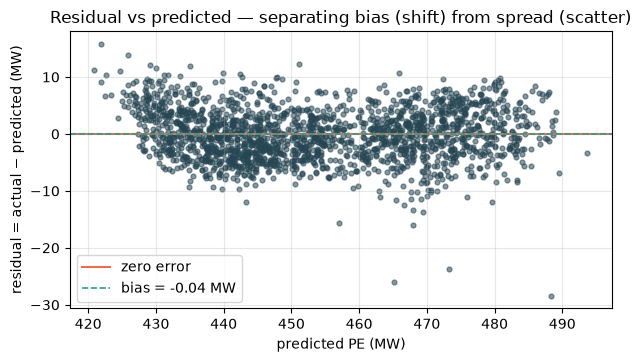

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.scatter(pred_pe, resid, s=12, color="#264653", alpha=0.55)
ax.axhline(0, color="#e76f51", linewidth=1.5, label="zero error")
ax.axhline(resid.mean(), color="#2a9d8f", linestyle="--", linewidth=1.2, label=f"bias = {resid.mean():+.2f} MW")
ax.set_xlabel("predicted PE (MW)")
ax.set_ylabel("residual = actual − predicted (MW)")
ax.set_title("Residual vs predicted — separating bias (shift) from spread (scatter)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**อ่านแบบงานสอบเทียบ:** residual กระจายรอบศูนย์โดยไม่มีรูปทรงโค้งชัดเจน → bias เกือบศูนย์ (−0.03 MW) ส่วน **spread ±4.5 MW (RMSE)** คือความละเอียดที่โมเดลนี้สัญญาได้ — รายงานได้ว่า "ทำนายกำลังไฟฟ้าได้ภายในประมาณ ±4.5 MW (1σ)" เหมือนที่เรารายงาน uncertainty บนใบสอบเทียบ ถ้า residual แผ่กว้างขึ้นเมื่อ predicted สูง (funnel) แปลว่าความละเอียดขึ้นกับช่วงวัด — เรื่องเดียวกับ heteroscedasticity ที่เจอบนเครื่องมือจริง

## 9. (ปิดท้าย) โมเดลคลาสิฟิเคชันก็ต้องสอบเทียบ probability ด้วย

ในงานสอบเทียบ เราไม่เชื่อค่าอ่านจนกว่าจะเช็กกับ reference — `predict_proba` ก็เช่นกัน: P(FAIL) = 0.3 ควรแปลว่า "กลุ่มชิ้นงานที่โมเดลให้ ~0.3 มีของเสียจริงราว 30%" **reliability diagram** (calibration curve) คือการเช็กนั้น: bin ความน่าจะเป็นทำนาย เทียบกับอัตราของเสียจริงในแต่ละ bin เส้นที่ตรงเส้นทแยง = สอบเทียบแล้ว

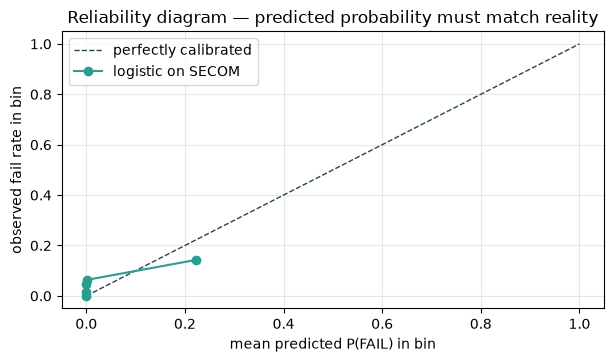

bin: predicted ~0.000 -> observed fail rate 0.000
bin: predicted ~0.000 -> observed fail rate 0.016
bin: predicted ~0.000 -> observed fail rate 0.048
bin: predicted ~0.001 -> observed fail rate 0.063
bin: predicted ~0.223 -> observed fail rate 0.143


In [13]:
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=5, strategy="quantile")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot([0, 1], [0, 1], color="#264653", linestyle="--", linewidth=1, label="perfectly calibrated")
ax.plot(mean_pred, frac_pos, color="#2a9d8f", marker="o", label="logistic on SECOM")
ax.set_xlabel("mean predicted P(FAIL) in bin")
ax.set_ylabel("observed fail rate in bin")
ax.set_title("Reliability diagram — predicted probability must match reality")
ax.legend()
ax.grid(alpha=0.3)
plt.show()
for mp, fp_ in zip(mean_pred, frac_pos):
    print(f"bin: predicted ~{mp:.3f} -> observed fail rate {fp_:.3f}")

**ข้อสังเกต:** โมเดลของเรา **มั่นใจเกินจริง** — หลาย bin ทำนาย P(FAIL) ใกล้ศูนย์ แต่ของเสียจริงใน bin นั้นมี 2–6% (โมเดล logistic บนข้อมูลไม่สมดุลมักออก probability สุดขั้ว) ในงานจริงที่ใช้ P(FAIL) ตัดสินใจเชิงต้นทุน เราต้องสอบเทียบ probability ก่อน (เช่น `CalibratedClassifierCV`) — เพราะ threshold sweep ในหัวข้อ 4 สมมติว่า **ลำดับ** ของ probability ใช้ได้ แต่ **ค่า** ของมันต้องผ่านการตรวจสอบเสียก่อน เหมือนค่าอ่านเครื่องมือที่ยังไม่ผ่านการสอบเทียบ

## 10. สรุปโมดูล

- **Confusion matrix ก่อนเสมอ** — แยก false accept (ปล่อยของเสียผ่าน, แพงสุด) จาก false reject (ตัดของดีทิ้ง) accuracy ตัวเดียวกลืนความต่างนี้หาย
- **ข้อมูลไม่สมดุล → ลืม accuracy** — รายงาน precision/recall/F1 และเลือก threshold จากต้นทุนความผิดพลาดจริงของ QC lab
- **PR-AUC ซื่อสัตย์กว่า ROC-AUC** บนข้อมูลที่ positive จิ๋ว (6.6%) — เส้นฐานของ PR คืออัตราของเสีย ไม่ใช่ 50%
- **CV spread = repeatability ของการประเมิน** — อย่าสรุปความต่างของโมเดลที่เล็กกว่า spread
- **Random split บนข้อมูลผลิตที่ drift ให้คะแนนสวยเกินจริง** — รายงาน time split คู่ไว้เสมอ เหมือนบันทึกช่วงการสอบเทียบ
- **Regression: RMSE/MAE/R² บอกคนละเรื่อง** — และ residual plot แยก bias ออกจาก spread แบบเดียวกับงานสอบเทียบ
- **probability ต้องสอบเทียบด้วย** — reliability diagram คือใบ certificate ของ `predict_proba`